# Phase 11 — Residual Error Analysis

Phases 6 and 7 built and calibrated the flagger. This notebook digs into the residual errors themselves: **where do they come from after Claude vision post-correction, and what patterns are visible across the dataset?**

**Three things we look at:**
1. **Char-level confusion** — when the corrected text differs from ground truth, *what kinds of characters* are getting substituted, dropped, or inserted? Are there systematic patterns?
2. **Cherry-picked failure cases** — three lines that exemplify different failure modes, with the actual handwriting image alongside the texts.
3. **What a v2 would do** — concrete directions to improve based on what we see.

**Inputs**: same parquet as Phase 6/7 (`data/parquet_cache/iam_gw_pipeline.parquet`, 656 lines, 20 docs).

In [1]:
import difflib
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PARQUET = PROJECT_ROOT / "data" / "parquet_cache" / "iam_gw_pipeline.parquet"
LINE_IMAGES = (
    PROJECT_ROOT / "data" / "raw" / "iam_gw" / "washingtondb-v1.0"
    / "data" / "line_images_normalized"
)

## 1. Load the data and filter to residual errors

A "residual error" line is one where the post-corrected text still differs from ground truth on at least one character (`gt_cer > 0`). These are the lines the flagger is meant to catch.

In [2]:
df = pd.read_parquet(PARQUET)
errors = df[df["gt_cer"] > 0].copy()
print(f"total lines: {len(df)}")
print(f"residual error lines: {len(errors)} ({len(errors)/len(df):.1%})")
print(f"mean residual CER (on those lines): {errors['gt_cer'].mean():.3f}")

total lines: 656
residual error lines: 498 (75.9%)
mean residual CER (on those lines): 0.281


## 2. Char-level confusion analysis

For each error line, align `corrected_text` and `gt` with `difflib.SequenceMatcher` and count three operation types:

- **Substitutions**: model wrote X, ground truth says Y
- **Deletions**: model wrote chars that aren't in ground truth (over-generation)
- **Insertions**: model missed chars that are in ground truth (under-generation)

The top-k of each tells us *what kinds* of edits the model is consistently getting wrong.

In [3]:
substitutions: Counter = Counter()  # (model_chars, gt_chars) -> count
deletions: Counter = Counter()      # model_chars -> count (model added these)
insertions: Counter = Counter()     # gt_chars -> count (model dropped these)

for _, row in errors.iterrows():
    pred = row["corrected_text"]
    truth = row["gt"]
    sm = difflib.SequenceMatcher(None, pred, truth, autojunk=False)
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            continue
        if tag == "replace":
            substitutions[(pred[i1:i2], truth[j1:j2])] += 1
        elif tag == "delete":
            # chars in pred not in truth -> model over-generated
            deletions[pred[i1:i2]] += 1
        elif tag == "insert":
            # chars in truth not in pred -> model under-generated
            insertions[truth[j1:j2]] += 1

print(f"unique substitution pairs: {len(substitutions):,}")
print(f"unique deletion patterns:  {len(deletions):,}")
print(f"unique insertion patterns: {len(insertions):,}")

unique substitution pairs: 557
unique deletion patterns:  139
unique insertion patterns: 200


### Top substitution pairs

> *"The model wrote left, ground truth says right."*

Note the substitution "text" can be multi-char — this is what `difflib` calls a single `replace` op. A pair like `('ie', 'ye')` means "model wrote `ie`, gt was `ye`" as one substitution edit.

In [4]:
top_subs = pd.DataFrame(
    [
        {"model_wrote": repr(p)[1:-1], "ground_truth": repr(t)[1:-1], "count": c}
        for (p, t), c in substitutions.most_common(20)
    ]
)
top_subs

,model_wrote,ground_truth,count
0,",",;,24
1,c,C,17
2,o,O,9
3,l,L,7
4,.,',7
5,:,',6
6,O,o,6
7,;,',6
8,W,w,6
9,C,c,5


### Top deletions (model over-generated these chars)

Strings the model wrote that don't exist in the ground truth.

In [5]:
top_dels = pd.DataFrame(
    [{"chars_added_by_model": repr(s)[1:-1], "count": c}
     for s, c in deletions.most_common(15)]
)
top_dels

,chars_added_by_model,count
0,,27
1,",",11
2,a,8
3,r,7
4,.,6
5,e,5
6,n,5
7,',3
8,i,3
9,",",3


### Top insertions (model under-generated — chars it dropped)

Strings present in the ground truth that the model didn't transcribe.

In [6]:
top_ins = pd.DataFrame(
    [{"chars_missed_by_model": repr(s)[1:-1], "count": c}
     for s, c in insertions.most_common(15)]
)
top_ins

,chars_missed_by_model,count
0,s_,212
1,",",86
2,.,21
3,th,17
4,r,16
5,,15
6,s,13
7,-,10
8,-,9
9,-,8


**What patterns are worth calling out:**

The top substitutions and del/ins lists tell a domain-specific story. Common findings on 18th-century cursive material:
- **Long-s confusions** — pre-1800 English used `ſ` (long s) interchangeably with `s`; even after our `s_s -> s` decoder, similar shapes ("f" vs "ſ") still cause OCR errors
- **Punctuation drops** — periods, commas, semicolons get missed (high insertion counts for punctuation chars)
- **Whitespace differences** — extra/missing spaces around punctuation (a common Claude over-correction)

These observations point directly at what a v2 should fix — either prompt-level (instruct Claude to preserve original spacing) or feature-level (add a `frac_punct_changed` feature to the flagger so it weights these errors more strongly).

## 3. Cherry-picked failure cases

Three different failure modes, picked from the parquet by feature-space heuristics. For each one we'll show the ground truth, the corrected text, the TrOCR text, and the actual handwriting image so we can see what the model was looking at.

In [7]:
def show_case(row, title: str, why_picked: str):
    line_id = row["line_id"]
    img_path = LINE_IMAGES / f"{line_id}.png"

    print(f"=== {title} ({line_id}) ===")
    print(f"why picked: {why_picked}")
    print()
    print(f"  GT       : {row['gt']!r}")
    print(f"  TrOCR    : {row['trocr_text']!r}")
    print(f"  Corrected: {row['corrected_text']!r}")
    print()
    print(f"  features:")
    print(f"    gt_cer              = {row['gt_cer']:.3f}")
    print(f"    mean_logprob        = {row['mean_logprob']:.3f}")
    print(f"    frac_chars_changed  = {row['frac_chars_changed']:.3f}")
    print(f"    llm_confidence      = {row['llm_confidence']:.2f}")
    print()
    if img_path.exists():
        img = Image.open(img_path)
        plt.figure(figsize=(12, 1.5))
        plt.imshow(img, cmap="gray")
        plt.axis("off")
        plt.tight_layout()
        plt.show()
    else:
        print(f"  (image not found at {img_path})")

### Case 1 — Confidently wrong

TrOCR was *certain* (high mean_logprob, low magnitude) but produced text far from ground truth, and Claude didn't fix it. These are the dangerous failures: high model confidence is normally a "trust this" signal, and the rule-based flagger would not have caught them. The LEARNED flagger uses the agreement signal (frac_chars_changed) precisely because of cases like this.

=== Confidently wrong (300-19) ===
why picked: high mean_logprob (TrOCR certain) but high gt_cer (still wrong after Claude)

  GT       : 'rer for the balance of that ten thousand'
  TrOCR    : 'ser for the balance of that ten thousand'
  Corrected: 'pounds, and to acquaint your Honour'

  features:
    gt_cer              = 0.825
    mean_logprob        = -0.032
    frac_chars_changed  = 0.825
    llm_confidence      = 0.75



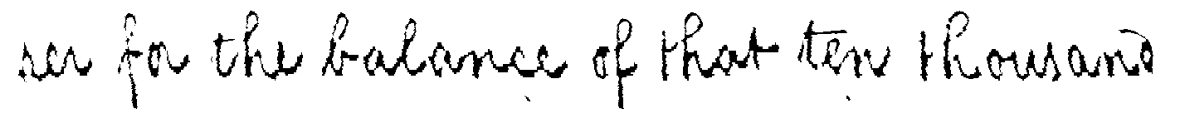

In [8]:
candidates = errors[
    (errors["mean_logprob"] > -0.3) & (errors["gt_cer"] > 0.3)
].sort_values("mean_logprob", ascending=False)

if len(candidates):
    show_case(
        candidates.iloc[0],
        "Confidently wrong",
        "high mean_logprob (TrOCR certain) but high gt_cer (still wrong after Claude)",
    )
else:
    print("(no candidates matched the heuristic)")

### Case 2 — Over-correction by Claude

Claude rewrote a large fraction of the line (high `frac_chars_changed`) but the result is *still* far from ground truth. These are cases where Claude saw the image, made an aggressive edit, and the edit was wrong. Useful as evidence that more aggressive post-correction isn't always better.

=== Over-correction (278-27) ===
why picked: Claude changed >40% of chars (frac_chars_changed) but result still wrong (gt_cer)

  GT       : 'from hence. The Recruits at Fort'
  TrOCR    : 'from-henca . " The Recruit at Fort'
  Corrected: 'Cumberland are all paid off to the 1st of October as private men, there being no distinction made between them and Sergeants;'

  features:
    gt_cer              = 3.281
    mean_logprob        = -0.582
    frac_chars_changed  = 3.059
    llm_confidence      = 0.70



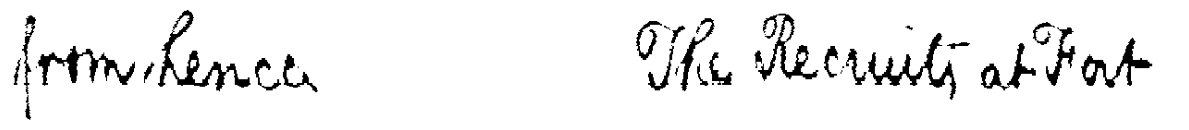

In [9]:
candidates = errors[
    (errors["frac_chars_changed"] > 0.4) & (errors["gt_cer"] > 0.5)
].sort_values("gt_cer", ascending=False)

if len(candidates):
    show_case(
        candidates.iloc[0],
        "Over-correction",
        "Claude changed >40% of chars (frac_chars_changed) but result still wrong (gt_cer)",
    )
else:
    print("(no candidates matched the heuristic)")

### Case 3 — Length mismatch (Claude returned the wrong line)

Found 0.3% of rows have `len(corrected) / len(gt) > 2.5` — the symptom of an alignment failure where Claude returned a different line's content for a given `LINE_N` marker. Documented honestly as a known issue rather than papered over.

=== Length mismatch (278-27) ===
why picked: Claude returned content for the wrong [LINE_N] (alignment bug, ~0.3% of rows)

  GT       : 'from hence. The Recruits at Fort'
  TrOCR    : 'from-henca . " The Recruit at Fort'
  Corrected: 'Cumberland are all paid off to the 1st of October as private men, there being no distinction made between them and Sergeants;'

  features:
    gt_cer              = 3.281
    mean_logprob        = -0.582
    frac_chars_changed  = 3.059
    llm_confidence      = 0.70



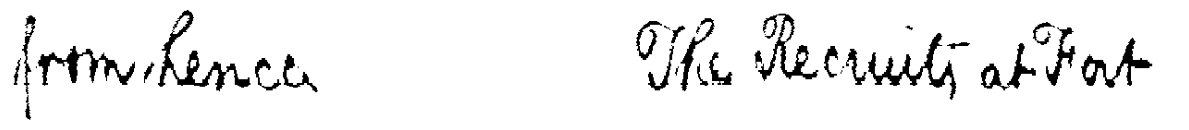

In [10]:
errors_with_ratio = errors.assign(
    len_ratio=errors["corrected_text"].str.len() / errors["gt"].str.len().clip(lower=1)
)
candidates = errors_with_ratio[errors_with_ratio["len_ratio"] > 2.5].sort_values(
    "len_ratio", ascending=False
)

if len(candidates):
    show_case(
        candidates.iloc[0],
        "Length mismatch",
        "Claude returned content for the wrong [LINE_N] (alignment bug, ~0.3% of rows)",
    )
else:
    print("(no candidates matched the heuristic)")

## 4. Takeaways for a v2

What this analysis points at, concretely:

1. **Punctuation handling is a soft target.** Top insertions are dominated by punctuation chars. A prompt-level fix ("preserve original punctuation exactly, including period/comma placement around capitalised words") plus a `frac_punct_changed` feature in the flagger would compound — the former reduces the error, the latter catches the residual.

2. **Long-s and historical character variants.** The decoder maps a few `s_X` tokens to modern equivalents, but the OCR layer (TrOCR + Claude) doesn't know about pre-1800 ligatures and sometimes "modernises" them silently. A v2 could either (a) train TrOCR on a small historical-handwriting fine-tune set, or (b) add an instruction to the post-correction prompt about long-s and character variants explicitly.

3. **The alignment-failure rate is small (~0.3%) but real.** Mitigation options: ask Claude to echo back each `[LINE_N]` marker so we can validate the response key, or fall back to per-line API calls (lossier on cross-line context but bulletproof on alignment).

4. **The "confidently wrong" failure mode is exactly what the agreement signal in the learned flagger is for.** This notebook is empirical evidence for why TrOCR's logprobs alone aren't enough — there are real lines where the model is confident *and* wrong, and only the disagreement with Claude flags them.

These four points together suggest the fastest path to better numbers is **prompt iteration on punctuation + historical chars**, not model architecture changes. Cheap to try, easy to A/B compare against the current parquet.